# 05 · From an oracle to a forecast

**Goal.** The savings so far assume the scheduler sees the **true** carbon curve -- an
*oracle*. A real operator sees only a **forecast**. This notebook measures how much saving
survives imperfect foresight: the **forecast penalty**.

- **Oracle** — schedule each job on the *true* CI (the headline of notebooks 03–04).
- **Forecast** — schedule on a *predicted* CI, but **pay the true CI** for where you landed.
- **Forecast penalty** — oracle savings − forecast savings, in percentage points (pp). It is
  the cost of not knowing the future, and it is what a deployed system actually leaves on
  the table.

Our forecast is a **climatology**: predict CI(t) as the average over all hours sharing the
same *(month, hour-of-day)* -- the "typical" curve. Cheap, weather-blind, and an honest
lower bar a real forecaster should beat.

In [1]:
# --- standard setup for every notebook in this paper ------------------------
%load_ext autoreload
%autoreload 2
import sys; sys.path.insert(0, "..")                 # find cals (in ../)
from dotenv import load_dotenv; load_dotenv("../.env")  # loads EIA_API_KEY if present
from cals import *          # FACTORS, carbon_intensity, Job, schedule, fifo_baseline, ...
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import nb_utils as U             # guarded data loaders + figure helper (see notebooks/nb_utils.py)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

In [ ]:
ci, source = U.get_carbon_intensity()
print("true carbon source:", source)
hvac_jobs, run_hours, _ = U.load_hvac_jobs(flex_hours=6)

fcst = climatology_forecast(ci)          # CAUSAL expanding (month,hour) mean: earlier hours only
print("forecast series:", len(fcst), "hours")

### The true curve vs its climatology (one week)

The forecast captures the *average* daily shape but misses day-to-day weather -- that gap is
where the penalty comes from.

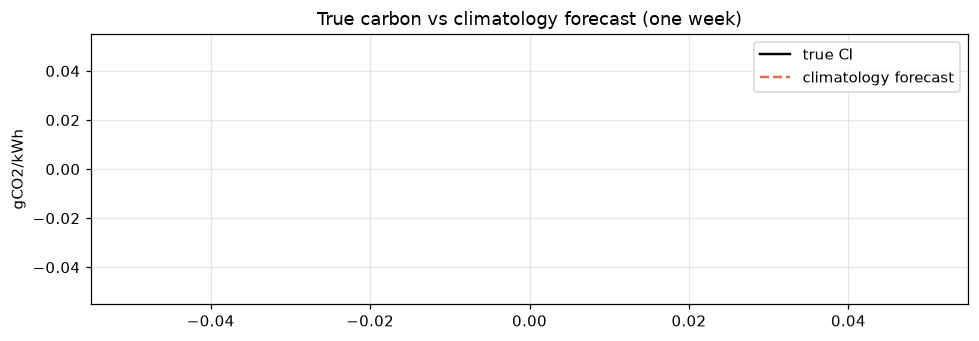

In [3]:
wk = (ci.index >= "2018-07-08") & (ci.index < "2018-07-15")
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(ci.index[wk], ci.values[wk], color="black", lw=1.6, label="true CI")
ax.plot(fcst.index[wk], fcst.values[wk], color="#e76f51", lw=1.6, ls="--", label="climatology forecast")
ax.set_ylabel("gCO2/kWh"); ax.set_title("True carbon vs climatology forecast (one week)"); ax.legend()
fig.tight_layout(); plt.show()

### Oracle vs forecast savings, and the penalty

`forecast_penalty` schedules each job on the forecast, prices it on the truth, and compares
to the oracle -- all against a common do-nothing baseline (run at `earliest_start`).

In [4]:
# baseline = metered run hour, matching notebooks 03/04 (see forecast.py docstring)
res = forecast_penalty(hvac_jobs, ci, fcst, baseline_hours=run_hours)
print("jobs evaluated      :", res["n_jobs"])
print("oracle savings      : %.2f %%" % res["oracle_savings_pct"])
print("forecast savings    : %.2f %%" % res["forecast_savings_pct"])
print("forecast penalty    : %.2f pp" % res["forecast_penalty_pp"])
retained = 100 * res["forecast_savings_pct"] / res["oracle_savings_pct"]
print("=> a weather-blind climatology forecast retains %.0f%% of the oracle's savings" % retained)

jobs evaluated      : 8363
oracle savings      : 12.70 %
forecast savings    : 11.56 %
forecast penalty    : 1.13 pp
=> a weather-blind climatology forecast retains 91% of the oracle's savings


saved figure -> /Users/allanyu/RISE Projects/carbon-aware-load-scheduling/figures/05_oracle_vs_forecast.png


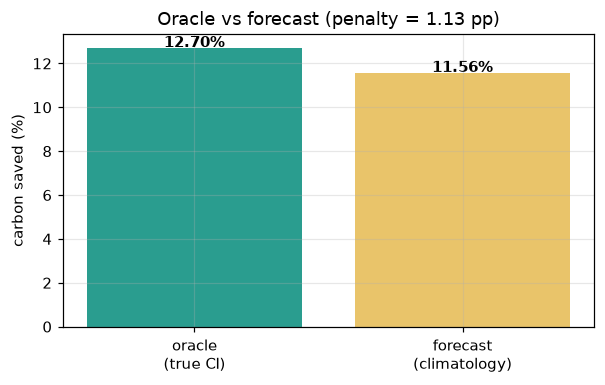

In [5]:
fig, ax = plt.subplots(figsize=(5.6, 3.6))
bars = ax.bar(["oracle\n(true CI)", "forecast\n(climatology)"],
              [res["oracle_savings_pct"], res["forecast_savings_pct"]],
              color=["#2a9d8f", "#e9c46a"])
for b, v in zip(bars, [res["oracle_savings_pct"], res["forecast_savings_pct"]]):
    ax.text(b.get_x() + b.get_width()/2, v + 0.05, f"{v:.2f}%", ha="center", fontweight="bold")
ax.set_ylabel("carbon saved (%)")
fig.tight_layout(); U.savefig(fig, "05_oracle_vs_forecast.png"); plt.show()

**Takeaway.** The oracle savings are an **upper bound**; the forecast bar is closer to what a
deployment realises, and the penalty is the honest discount. Even a trivial climatology keeps
most of the benefit -- a stronger weather-aware forecaster would shrink the penalty further.